## imports and load:

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from data_loader import load_transactions
from preprocessor import preprocess_transactions
from feature_engineering import add_velocity_features, add_risk_score

print("Loading data...")
df = load_transactions()
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(df.head(3))

Loading data...
Loaded: 1,852,394 rows x 22 cols
  trans_date_trans_time            cc_num                         merchant  \
0   2019-01-01 00:00:18  2703186189652095       fraud_Rippin, Kub and Mann   
1   2019-01-01 00:00:44      630423337322  fraud_Heller, Gutmann and Zieme   
2   2019-01-01 00:00:51    38859492057661             fraud_Lind-Buckridge   

        category     amt      first     last gender  \
0       misc_net    4.97   Jennifer    Banks      F   
1    grocery_pos  107.23  Stephanie     Gill      F   
2  entertainment  220.11     Edward  Sanchez      M   

                         street            city  ...      lat      long  \
0                561 Perry Cove  Moravian Falls  ...  36.0788  -81.1781   
1  43039 Riley Greens Suite 393          Orient  ...  48.8878 -118.2105   
2      594 White Dale Suite 530      Malad City  ...  42.1808 -112.2620   

   city_pop                                job         dob  \
0      3495          Psychologist, counselling  1988-0

## preprocess:

In [2]:
df = preprocess_transactions(df)

print("New columns added:")
print(df[['trans_date_trans_time','hour','dayofweek','month',
          'is_night','is_high_risk_merchant','is_high_amount']].head(10))

New columns added:
  trans_date_trans_time  hour  dayofweek  month  is_night  \
0   2019-01-01 00:00:18     0          1      1         1   
1   2019-01-01 00:00:44     0          1      1         1   
2   2019-01-01 00:00:51     0          1      1         1   
3   2019-01-01 00:01:16     0          1      1         1   
4   2019-01-01 00:03:06     0          1      1         1   
5   2019-01-01 00:04:08     0          1      1         1   
6   2019-01-01 00:04:42     0          1      1         1   
7   2019-01-01 00:05:08     0          1      1         1   
8   2019-01-01 00:05:18     0          1      1         1   
9   2019-01-01 00:06:01     0          1      1         1   

   is_high_risk_merchant  is_high_amount  
0                      1               0  
1                      1               0  
2                      0               0  
3                      0               0  
4                      0               0  
5                      0               0  
6       

## velocity features:

In [3]:
print("Adding velocity features (takes 1-2 mins on 1.8M rows)...")
df = add_velocity_features(df)

print("\nVelocity feature sample:")
print(df[['cc_num','unix_time','time_diff_1','time_diff_4','velocity_flag']].dropna().head(10))

print("\nVelocity flag distribution:")
print(df['velocity_flag'].value_counts())

Adding velocity features (takes 1-2 mins on 1.8M rows)...

Velocity feature sample:
            cc_num   unix_time  time_diff_1  time_diff_4  velocity_flag
2907   60416207185  1325509846       1952.0      87811.0              0
4135   60416207185  1325598995      89149.0     105098.0              0
4337   60416207185  1325610310      11315.0     116254.0              0
5467   60416207185  1325685595      75285.0     177701.0              0
6027   60416207185  1325711842      26247.0     201996.0              0
6273   60416207185  1325724144      12302.0     125149.0              0
7473   60416207185  1325799260      75116.0     188950.0              0
8351   60416207185  1325845549      46289.0     159954.0              0
10739  60416207185  1325941099      95550.0     229257.0              0
12714  60416207185  1326009923      68824.0     285779.0              0

Velocity flag distribution:
velocity_flag
0    1844477
1       6944
2        973
Name: count, dtype: int64


##  risk score:

In [4]:
df = add_risk_score(df)

print("Risk tier distribution:")
print(df['risk_tier'].value_counts())

print("\nFraud rate per tier:")
print(df.groupby('risk_tier')['is_fraud'].agg(['sum','count','mean'])
        .rename(columns={'sum':'fraud','count':'total','mean':'fraud_rate'})
        .sort_values('fraud_rate', ascending=False))

Risk tier distribution:
risk_tier
LOW         1123758
MEDIUM       597889
HIGH         126333
CRITICAL       4414
Name: count, dtype: int64

Fraud rate per tier:
           fraud    total  fraud_rate
risk_tier                            
CRITICAL    2936     4414    0.665156
HIGH        3473   126333    0.027491
MEDIUM      2811   597889    0.004702
LOW          431  1123758    0.000384


##  feature correlation heatmap:

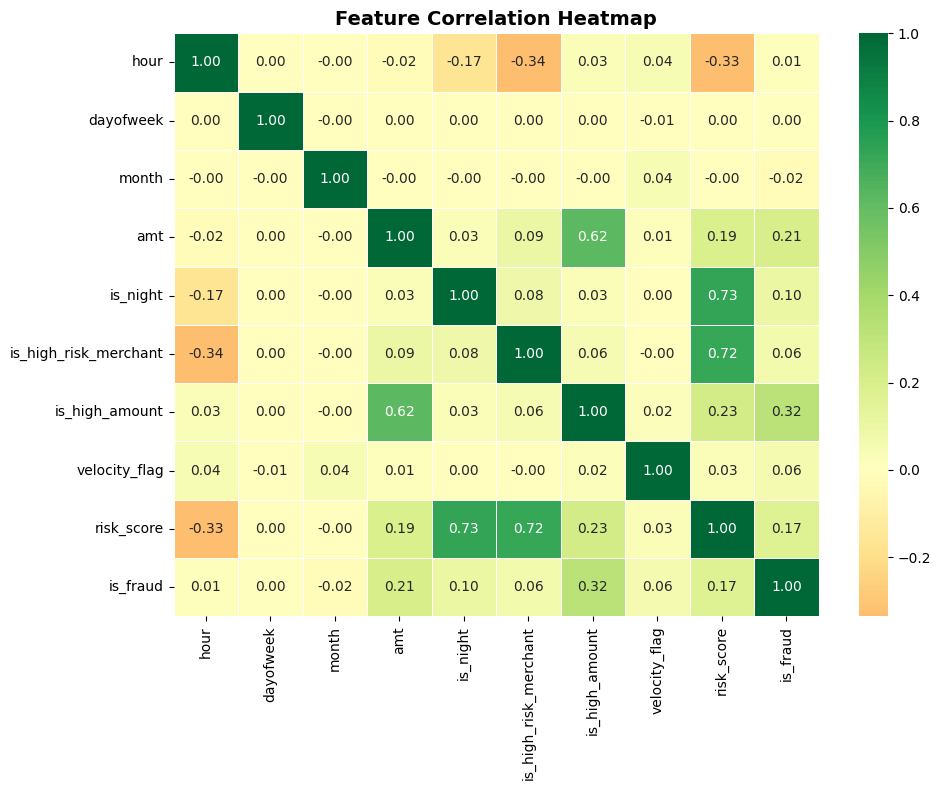

Saved!


In [5]:
features = ['hour','dayofweek','month','amt','is_night',
            'is_high_risk_merchant','is_high_amount',
            'velocity_flag','risk_score','is_fraud']

corr = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

##  save processed data:

In [6]:
cols_to_save = ['cc_num','amt','category','is_fraud','hour','dayofweek',
                'month','is_night','is_high_risk_merchant','is_high_amount',
                'velocity_flag','risk_score','risk_tier',
                'V1' if 'V1' in df.columns else 'unix_time']

save_cols = [c for c in cols_to_save if c in df.columns]
df[save_cols].to_csv("../data/processed_data.csv", index=False)
print(f"Saved processed_data.csv — {df.shape[0]:,} rows")
print("Columns saved:", save_cols)

Saved processed_data.csv — 1,852,394 rows
Columns saved: ['cc_num', 'amt', 'category', 'is_fraud', 'hour', 'dayofweek', 'month', 'is_night', 'is_high_risk_merchant', 'is_high_amount', 'velocity_flag', 'risk_score', 'risk_tier', 'unix_time']
